<a href="https://colab.research.google.com/github/aaryaddeshmukh10/Aml-experiments-Aarya-Deshmukh/blob/main/AML_Exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Dataset**

In [ ]:
file_path = '/content/drive/MyDrive/bank/bank.csv'
df = pd.read_csv(file_path, sep=';')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


**Dataset Information**

In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(4521, 17)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None

Statistical Summary:
               age      

**Check Target Variable Distribution**

In [ ]:
df['y'].value_counts()

,count
y,
no,4000
yes,521


**Visualize Subscription Distribution**

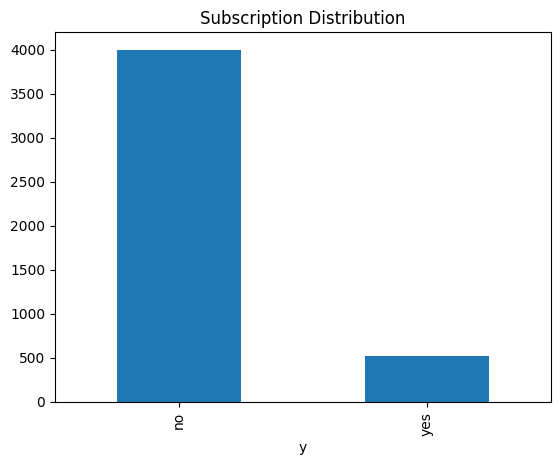

In [ ]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar')
plt.title("Subscription Distribution")
plt.show()

**Visualize Job vs Subscription**

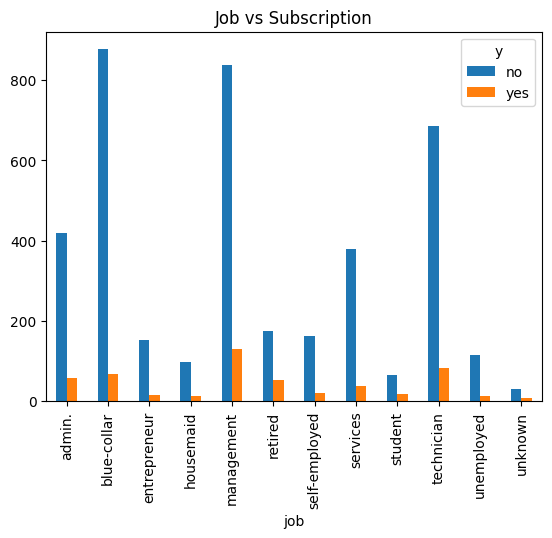

In [ ]:
pd.crosstab(df['job'], df['y']).plot(kind='bar')
plt.title("Job vs Subscription")
plt.show()

**Select Important Features**

In [ ]:
selected_features = [
    'age',
    'job',
    'balance',
    'housing',
    'loan',
    'duration',
    'campaign',
    'poutcome'
]
print("Selected Features:")
print(selected_features)

Selected Features:
['age', 'job', 'balance', 'housing', 'loan', 'duration', 'campaign', 'poutcome']


**Encode Categorical Data**

In [ ]:
le = LabelEncoder()

for col in selected_features:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Encode Target Variable
df['y'] = df['y'].map({
    'yes': 1,
    'no': 0
})

print("Encoding Completed")

Encoding Completed


**Split Features and Target**

In [ ]:
X = df[selected_features]

y = df['y']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age  job  balance  housing  loan  duration  campaign  poutcome
0   30   10     1787        0     0        79         1         3
1   33    7     4789        1     1       220         1         0
2   35    4     1350        1     0       185         1         0
3   30    4     1476        1     1       199         4         3
4   59    1        0        1     0       226         1         3

Target:
0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64


**Split Training and Testing Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Size:", len(X_train))

print("Testing Data Size:", len(X_test))

Training Data Size: 3616
Testing Data Size: 905


**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Train Logistic Regression Model**

In [ ]:
#Logisitc Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**Train Random Forest Model**

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**Evaluate Logistic Regression Model**

In [ ]:
print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.8883977900552487

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       807
           1       0.46      0.16      0.24        98

    accuracy                           0.89       905
   macro avg       0.68      0.57      0.59       905
weighted avg       0.86      0.89      0.86       905



**Evaluate Random Forest Model**

In [ ]:
print("Random Forest Accuracy:")

print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.881767955801105

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       807
           1       0.40      0.18      0.25        98

    accuracy                           0.88       905
   macro avg       0.65      0.58      0.59       905
weighted avg       0.85      0.88      0.86       905



**Feature Importance**

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=selected_features
)

print("Feature Importance:\n")

print(importance.sort_values(ascending=False))

Feature Importance:

duration    0.368745
balance     0.194016
age         0.170739
job         0.085210
poutcome    0.079634
campaign    0.062690
housing     0.024990
loan        0.013974
dtype: float64
